# Autoencoder MNIST

## Importing required packages

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import torch 
import torch.nn as nn 
import torch.nn.functional as F
from  torch.utils.data import DataLoader, SubsetRandomSampler
import torch.optim
from torchvision import datasets,transforms

## Defining transforms

In [2]:
transforms=transforms.ToTensor()

## Downloading requried data

In [3]:
train_data=datasets.MNIST('data',train=True,download=True,transform=transforms)
test_data=datasets.MNIST('data',train=False,download=True,transform=transforms)

100%|██████████| 9.91M/9.91M [00:07<00:00, 1.27MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 879kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.74MB/s]


## Defining dataloaders

In [4]:
valid_size=0.2

# IMPORTANT 
batch_size=20

num_workers=0

train_length = len(train_data)

# obtain training dataset indices that will be used for validation dataset
indices = list(range(train_length))

np.random.shuffle(indices)
split = int(np.floor(valid_size * train_length))
train_idx, valid_idx = indices[split:], indices[:split]

# define samplers for obtaining training and validation batches
train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

# prepare data loaders for train, test and validation dataset
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
    sampler=train_sampler, num_workers=num_workers)
valid_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, 
    sampler=valid_sampler, num_workers=num_workers)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, 
    num_workers=num_workers)

In [5]:

# Printing the length of our train, valid and test dataloaders
# NOTE : Here batch size is 20
len(train_loader),len(valid_loader),len(test_loader)

(2400, 600, 500)

In [6]:
# checking our data
dataiter=iter(train_loader)
images,labels=next(dataiter)
print(images, images.shape, len(images), images[0].shape)
print()
print(labels,labels.shape,len(labels))

tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        ...,


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0.

## Visualizing a Training batch

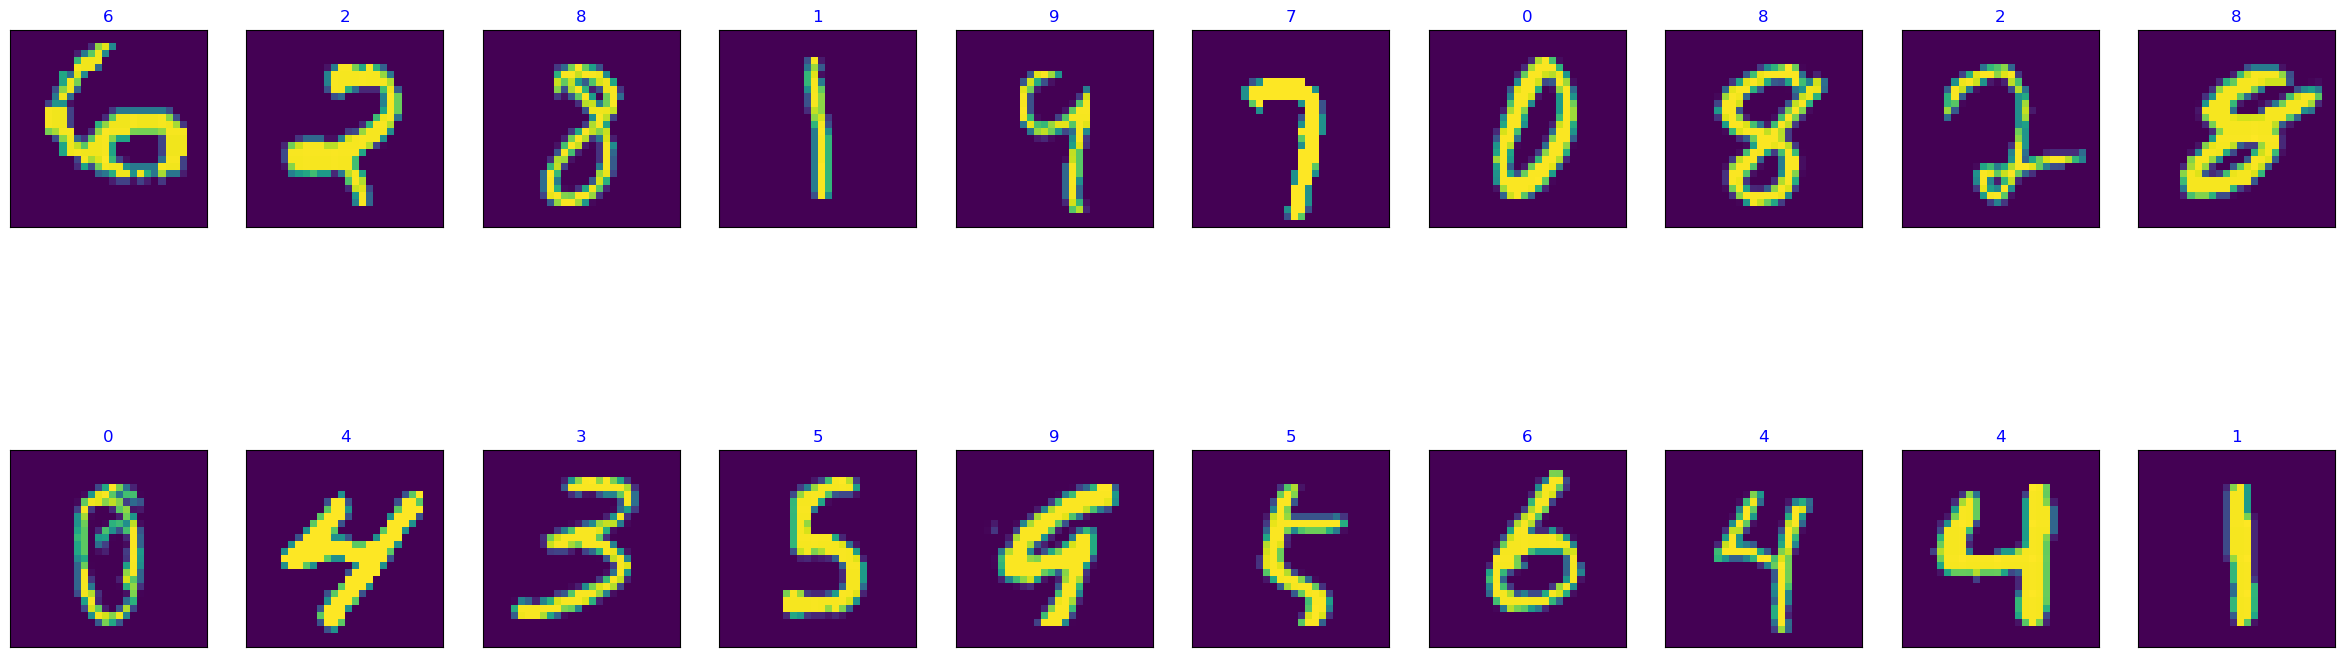

In [7]:
# Displaying images and labels of a batch
fig=plt.figure(figsize=(30,10))
for i in range(len(labels)):
    ax=fig.add_subplot(2,10,i+1,xticks=[],yticks=[])
    plt.imshow(np.squeeze(images[i]))
    ax.set_title(labels[i].item(),color='blue')

## Adding Noise (Denoising Autoencoder)

We create noisy versions of the input images by adding random Gaussian noise, then clip pixel values back to the valid `[0, 1]` range. The model will be trained to map **noisy image -> clean image**, which is the core denoising task.

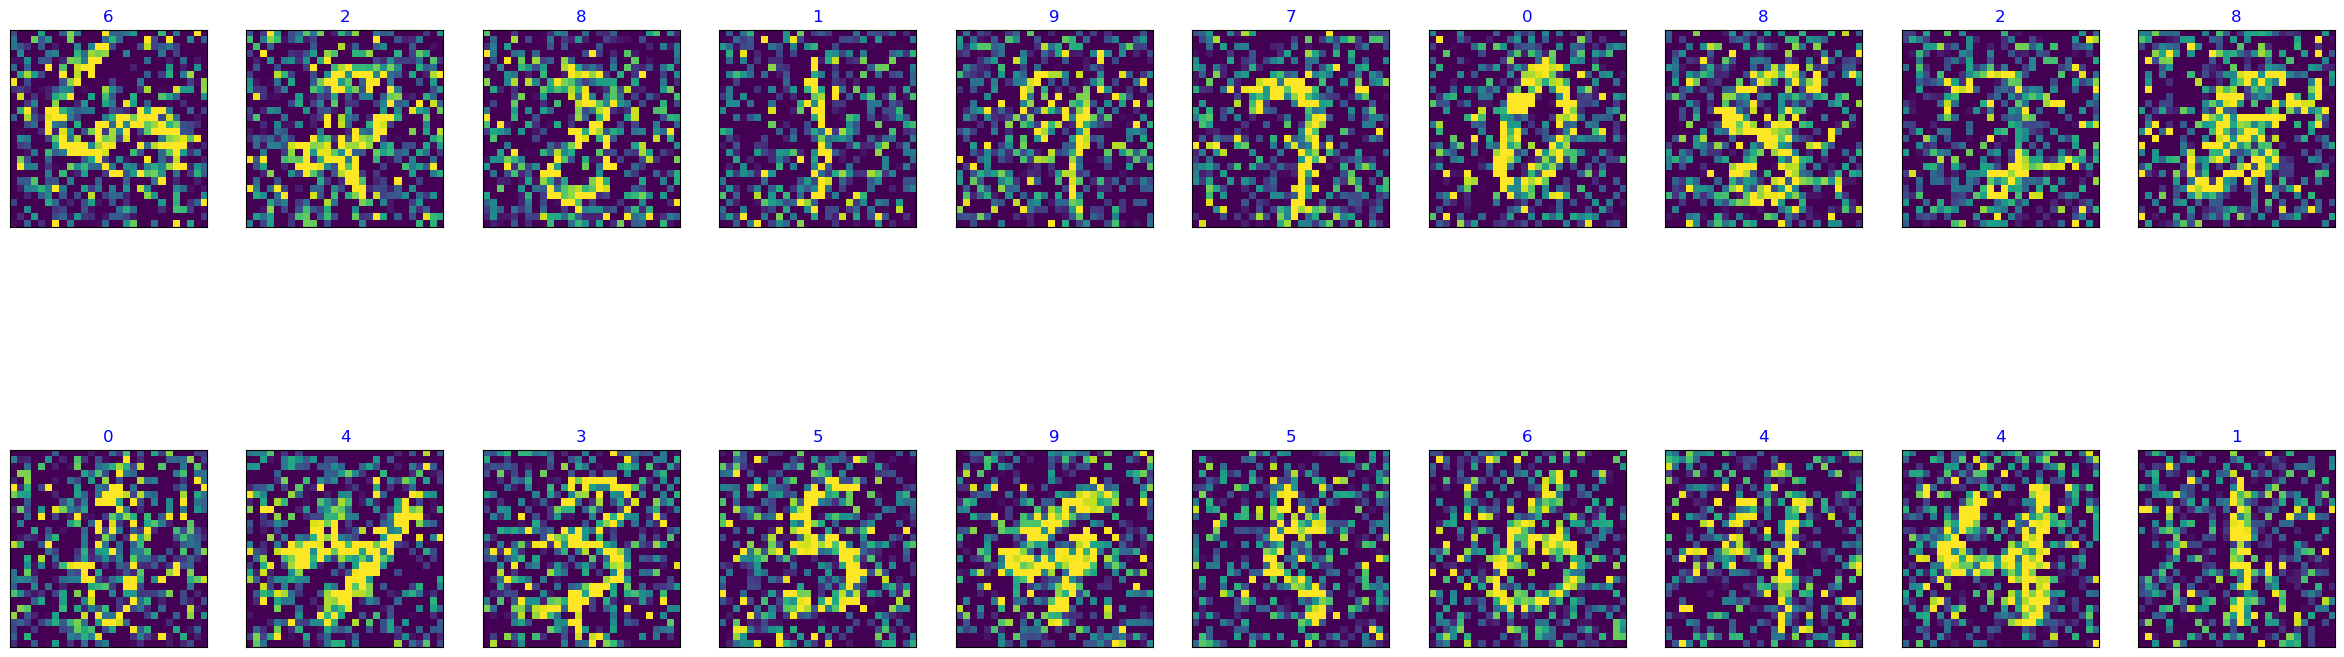

In [8]:
# Amount of noise to add. Higher = harder denoising task.
noise_factor = 0.5

def add_noise(imgs, noise_factor=noise_factor):
    """Adds Gaussian noise to a batch of images and clips to [0, 1]."""
    noisy_imgs = imgs + noise_factor * torch.randn(*imgs.shape)
    noisy_imgs = torch.clip(noisy_imgs, 0., 1.)
    return noisy_imgs

# Visualizing a noisy version of the same batch shown above
noisy_images = add_noise(images)

fig=plt.figure(figsize=(30,10))
for i in range(len(labels)):
    ax=fig.add_subplot(2,10,i+1,xticks=[],yticks=[])
    plt.imshow(np.squeeze(noisy_images[i]))
    ax.set_title(labels[i].item(),color='blue')


## Defining Architecture

In [9]:
class F_Auto_MNIST(nn.Module):
    def __init__(self,en_dim):
        super(F_Auto_MNIST,self).__init__()
        self.encoder=nn.Linear(784,en_dim)
        self.decoder=nn.Linear(en_dim,784)
    
    def forward(self,x):
        x=F.relu(self.encoder(x))
        x=F.sigmoid(self.decoder(x))
        return x

class Tran_conv_Auto_MNIST(nn.Module):
    def __init__(self):
        super(Tran_conv_Auto_MNIST,self).__init__()
        self.en_conv1=nn.Conv2d(1,16,3,padding=1)
        self.en_conv2=nn.Conv2d(16,4,3,padding=1)
        self.pool=nn.MaxPool2d(2,2)

        self.de_conv1=nn.ConvTranspose2d(4,16,2,stride=2)
        self.de_conv2=nn.ConvTranspose2d(16,1,2,stride=2)

    def forward(self,x):
        x=self.pool(F.relu(self.en_conv1(x)))
        x=self.pool(F.relu(self.en_conv2(x)))
        x=F.relu(self.de_conv1(x))
        x=F.sigmoid(self.de_conv2(x))
        return x

class upsamp_conv_Auto_MNIST(nn.Module):
    def __init__(self):
        super(upsamp_conv_Auto_MNIST,self).__init__()
        self.en_conv1=nn.Conv2d(1,16,3,padding=1)
        self.en_conv2=nn.Conv2d(16,4,3,padding=1)
        self.pool=nn.MaxPool2d(2,2)

        self.de_conv1=nn.Conv2d(4,16,3,padding=1)
        self.de_conv2=nn.Conv2d(16,1,3,padding=1)

    def forward(self,x):
        x=self.pool(F.relu(self.en_conv1(x)))
        x=self.pool(F.relu(self.en_conv2(x)))
        x = F.upsample(x, scale_factor=2, mode='nearest')
        x=F.relu(self.de_conv1(x))
        x = F.upsample(x, scale_factor=2, mode='nearest')
        x=F.sigmoid(self.de_conv2(x))
        return x

#Since the images are normalized between 0 and 1, we need to use a sigmoid activation on the output layer to get values that match this input value range.

In [10]:
model_1=F_Auto_MNIST(32)
model_2=Tran_conv_Auto_MNIST()
model_3=upsamp_conv_Auto_MNIST()

def weight_init_normal(m):
    classname=m.__class__.__name__
    if classname.find('Linear')!=-1:
        n = m.in_features
        y = (1.0/np.sqrt(n))
        m.weight.data.normal_(0, y)
        m.bias.data.fill_(0)

model_1.apply(weight_init_normal)

use_cuda=True
if use_cuda and torch.cuda.is_available():
  model_1.cuda()
  model_2.cuda()
  model_3.cuda()
print(model_1,'\n\n\n\n',model_2,'\n\n\n\n',model_3,'\n\n\n\n','On GPU : ',torch.cuda.is_available())

F_Auto_MNIST(
  (encoder): Linear(in_features=784, out_features=32, bias=True)
  (decoder): Linear(in_features=32, out_features=784, bias=True)
) 



 Tran_conv_Auto_MNIST(
  (en_conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (en_conv2): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (de_conv1): ConvTranspose2d(4, 16, kernel_size=(2, 2), stride=(2, 2))
  (de_conv2): ConvTranspose2d(16, 1, kernel_size=(2, 2), stride=(2, 2))
) 



 upsamp_conv_Auto_MNIST(
  (en_conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (en_conv2): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (de_conv1): Conv2d(4, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (de_conv2): Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
) 



 O

## Defining our Loss Function

In [11]:
# Used when comapring pixel values.
criterion=nn.MSELoss()

## Training and Validation Phase

In [12]:
def trainNet(model,lr,state='fully'):
    optimizer=torch.optim.Adam(model.parameters(),lr=lr)

    # Number of epochs to train for
    loss_keeper={'train':[],'valid':[]}
    epochs=20

    # minimum validation loss ----- set initial minimum to infinity
    valid_loss_min = np.inf 

    for epoch in range(epochs):
        train_loss=0.0
        valid_loss=0.0

        """
        TRAINING PHASE
        """
        model.train() # TURN ON DROPOUT for training
        for images,_ in train_loader:
            if use_cuda and torch.cuda.is_available():
                images=images.cuda()
            # clean images are the targets; noisy images are the model input
            noisy_images = add_noise(images)
            if state=='fully':
                images=images.view(images.size(0),-1)
                noisy_images=noisy_images.view(noisy_images.size(0),-1)
            optimizer.zero_grad()
            output=model(noisy_images)
            loss=criterion(output,images)
            loss.backward()
            optimizer.step()
            train_loss+=loss.item()

        """
        VALIDATION PHASE
        """
        model.eval() # TURN OFF DROPOUT for validation
        for images,_ in valid_loader:
            if use_cuda and torch.cuda.is_available():
                images=images.cuda()
            noisy_images = add_noise(images)
            if state=='fully':
                images=images.view(images.size(0),-1)
                noisy_images=noisy_images.view(noisy_images.size(0),-1)
            output=model(noisy_images)
            loss=criterion(output,images)
            valid_loss+=loss.item()

        # Calculating loss over entire batch size for every epoch
        train_loss = train_loss/len(train_loader)
        valid_loss = valid_loss/len(valid_loader)


        # saving loss values
        loss_keeper['train'].append(train_loss)
        loss_keeper['valid'].append(valid_loss)

        print(f"\nEpoch : {epoch+1}\tTraining Loss : {train_loss}\tValidation Loss : {valid_loss}")
        if valid_loss<=valid_loss_min:
            print(f"Validation loss decreased from : {valid_loss_min} ----> {valid_loss} ----> Saving Model.......")
            z=type(model).__name__
            torch.save(model.state_dict(), z+'_model.pth')
            valid_loss_min=valid_loss
    return(loss_keeper)


In [13]:
m1_loss=trainNet(model_1,0.01)


Epoch : 1	Training Loss : 0.043677866994403305	Validation Loss : 0.04053793547054132
Validation loss decreased from : inf ----> 0.04053793547054132 ----> Saving Model.......

Epoch : 2	Training Loss : 0.04052925453831752	Validation Loss : 0.040292862616479394
Validation loss decreased from : 0.04053793547054132 ----> 0.040292862616479394 ----> Saving Model.......

Epoch : 3	Training Loss : 0.04005317524075508	Validation Loss : 0.04012642100142936
Validation loss decreased from : 0.040292862616479394 ----> 0.04012642100142936 ----> Saving Model.......

Epoch : 4	Training Loss : 0.03983464852208272	Validation Loss : 0.0393237663898617
Validation loss decreased from : 0.04012642100142936 ----> 0.0393237663898617 ----> Saving Model.......

Epoch : 5	Training Loss : 0.039732408272102476	Validation Loss : 0.039068912031749885
Validation loss decreased from : 0.0393237663898617 ----> 0.039068912031749885 ----> Saving Model.......

Epoch : 6	Training Loss : 0.03965591405130302	Validation Loss

In [14]:
m2_loss=trainNet(model_2,0.01,'conv')


Epoch : 1	Training Loss : 0.03750955883568774	Validation Loss : 0.03325206726479034
Validation loss decreased from : inf ----> 0.03325206726479034 ----> Saving Model.......

Epoch : 2	Training Loss : 0.032895000016627214	Validation Loss : 0.032084577887629466
Validation loss decreased from : 0.03325206726479034 ----> 0.032084577887629466 ----> Saving Model.......

Epoch : 3	Training Loss : 0.03212072784701983	Validation Loss : 0.03155442738595108
Validation loss decreased from : 0.032084577887629466 ----> 0.03155442738595108 ----> Saving Model.......

Epoch : 4	Training Loss : 0.03166375101854404	Validation Loss : 0.031268055258939664
Validation loss decreased from : 0.03155442738595108 ----> 0.031268055258939664 ----> Saving Model.......

Epoch : 5	Training Loss : 0.0314203169158039	Validation Loss : 0.03112512129669388
Validation loss decreased from : 0.031268055258939664 ----> 0.03112512129669388 ----> Saving Model.......

Epoch : 6	Training Loss : 0.031237735190273574	Validation L

In [15]:
m3_loss=trainNet(model_3,0.01,'conv')

C:\Users\AASTHA\AppData\Local\Temp\ipykernel_22340\219568314.py:42: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x = F.upsample(x, scale_factor=2, mode='nearest')
C:\Users\AASTHA\AppData\Local\Temp\ipykernel_22340\219568314.py:44: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x = F.upsample(x, scale_factor=2, mode='nearest')



Epoch : 1	Training Loss : 0.11205085966425637	Validation Loss : 0.11220043068130811
Validation loss decreased from : inf ----> 0.11220043068130811 ----> Saving Model.......

Epoch : 2	Training Loss : 0.11195311656221747	Validation Loss : 0.11220043091724316

Epoch : 3	Training Loss : 0.11195311654669543	Validation Loss : 0.11220043061921994
Validation loss decreased from : 0.11220043068130811 ----> 0.11220043061921994 ----> Saving Model.......

Epoch : 4	Training Loss : 0.11195311680746575	Validation Loss : 0.1122004306068023
Validation loss decreased from : 0.11220043061921994 ----> 0.1122004306068023 ----> Saving Model.......

Epoch : 5	Training Loss : 0.11195311670191586	Validation Loss : 0.11220043061921994

Epoch : 6	Training Loss : 0.11195311679504812	Validation Loss : 0.11220043029636145
Validation loss decreased from : 0.1122004306068023 ----> 0.11220043029636145 ----> Saving Model.......

Epoch : 7	Training Loss : 0.11195311676400403	Validation Loss : 0.1122004306068023

Epoc

In [16]:
model_1.load_state_dict(torch.load('F_Auto_MNIST_model.pth'))
model_2.load_state_dict(torch.load('Tran_conv_Auto_MNIST_model.pth'))
model_3.load_state_dict(torch.load('upsamp_conv_Auto_MNIST_model.pth'))

<All keys matched successfully>

## Plotting Loss

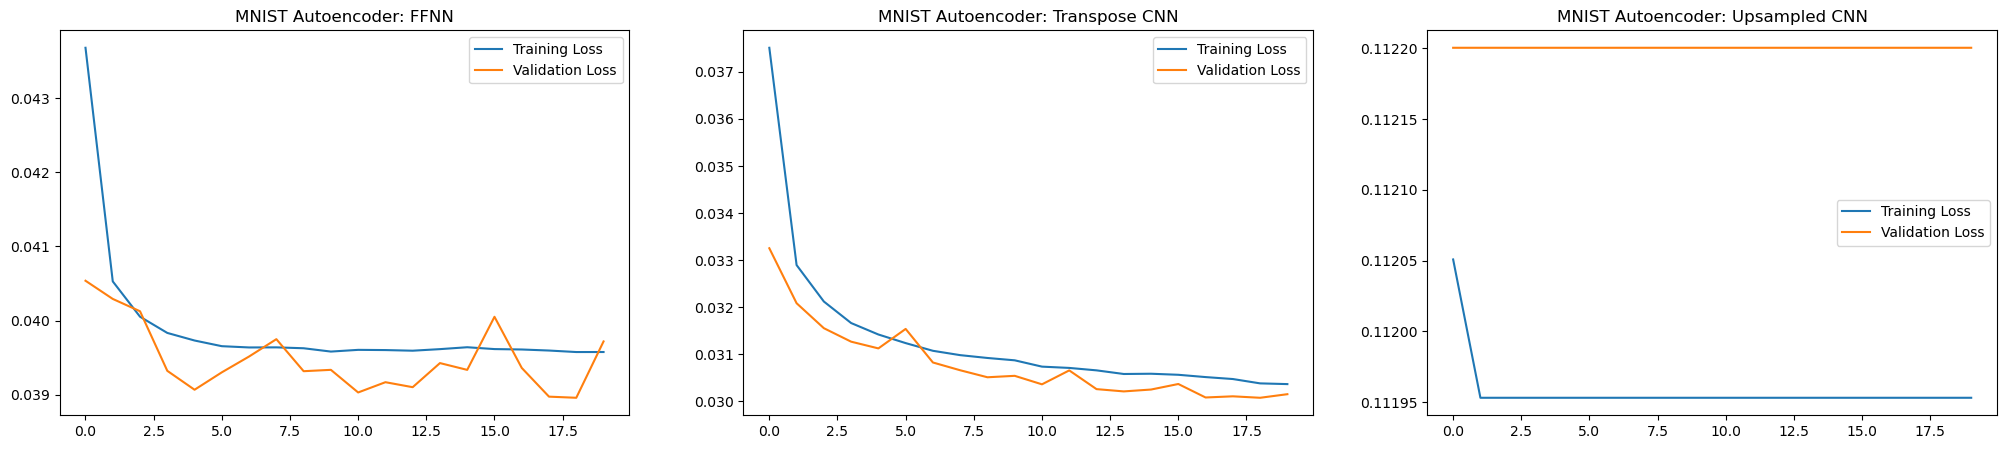

In [17]:
title=['FFNN','Transpose CNN','Upsampled CNN']
model_losses=[m1_loss,m2_loss,m3_loss]

fig=plt.figure(1,figsize=(25,5))
idx=1
for i in model_losses:
  ax=fig.add_subplot(1,3,idx)
  ax.plot(i['train'],label="Training Loss")
  ax.plot(i['valid'],label="Validation Loss")
  ax.set_title('MNIST Autoencoder: '+title[idx-1])
  idx+=1
  plt.legend();

## Testing Phase

In [18]:
def test(model,state='fully'):
    # obtain one batch of test images
    dataiter = iter(test_loader)
    images, _ = next(dataiter)
    if use_cuda and torch.cuda.is_available():
        images=images.cuda()

    # create the noisy version that is actually fed to the model
    noisy_images = add_noise(images)

    model_input = noisy_images
    if state=='fully':
        model_input = noisy_images.view(noisy_images.size(0), -1)

    # get sample outputs (denoised reconstructions)
    output = model(model_input)
    # prep images for display
    images = images.cpu().numpy()
    noisy_images = noisy_images.cpu().numpy()
    # output is resized into a batch of images
    output = output.view(batch_size, 1, 28, 28)
    # use detach when it's an output that requires_grad
    output = output.cpu().detach().numpy()


    # plot original, noisy, and denoised images: one row each
    fig, axes = plt.subplots(nrows=3, ncols=10, sharex=True, sharey=True, figsize=(25,6))

    row_labels = ['Original', 'Noisy', 'Denoised']
    for row_idx, (imgs, row) in enumerate(zip([images, noisy_images, output], axes)):
        for img, ax in zip(imgs, row):
            if state=='fully':
                img = img.reshape(1, 28, 28)
            ax.imshow(np.squeeze(img), cmap='gray')
            ax.get_xaxis().set_visible(False)
            ax.get_yaxis().set_visible(False)
        row[0].set_ylabel(row_labels[row_idx], fontsize=14, rotation=90, labelpad=10)
        row[0].get_yaxis().set_visible(True)
        row[0].set_yticks([])


## FFNN Autoencoder

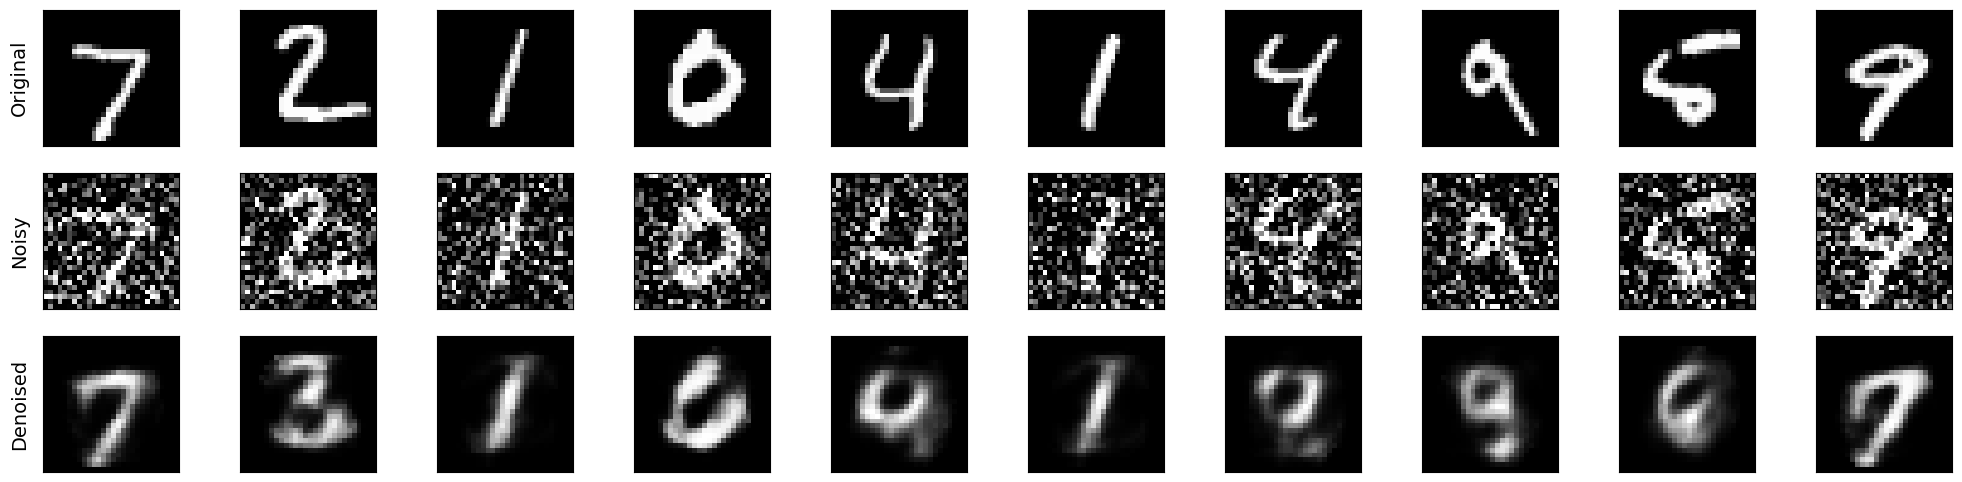

In [19]:
test(model_1)

## Transpose CNN Autoencoder

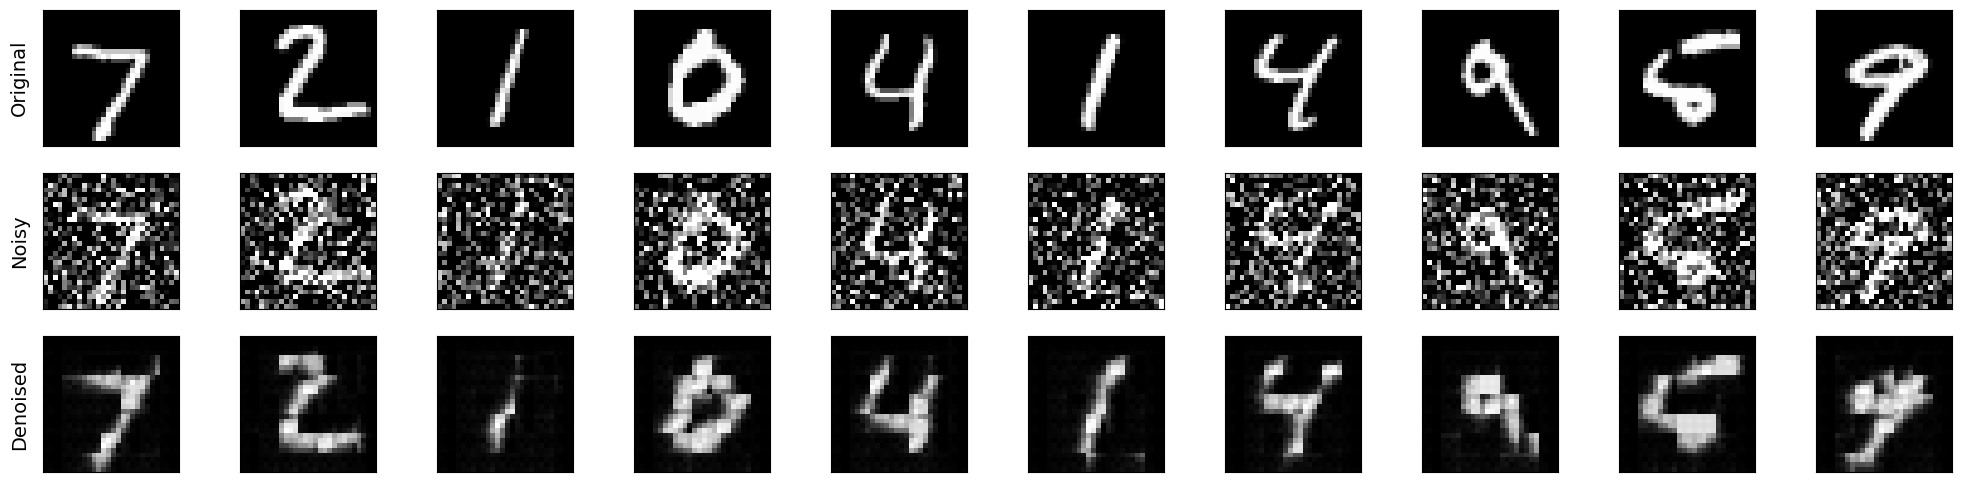

In [20]:
test(model_2,'conv')

## Upsampled CNN Autoencoder

C:\Users\AASTHA\AppData\Local\Temp\ipykernel_22340\219568314.py:42: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x = F.upsample(x, scale_factor=2, mode='nearest')
C:\Users\AASTHA\AppData\Local\Temp\ipykernel_22340\219568314.py:44: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x = F.upsample(x, scale_factor=2, mode='nearest')


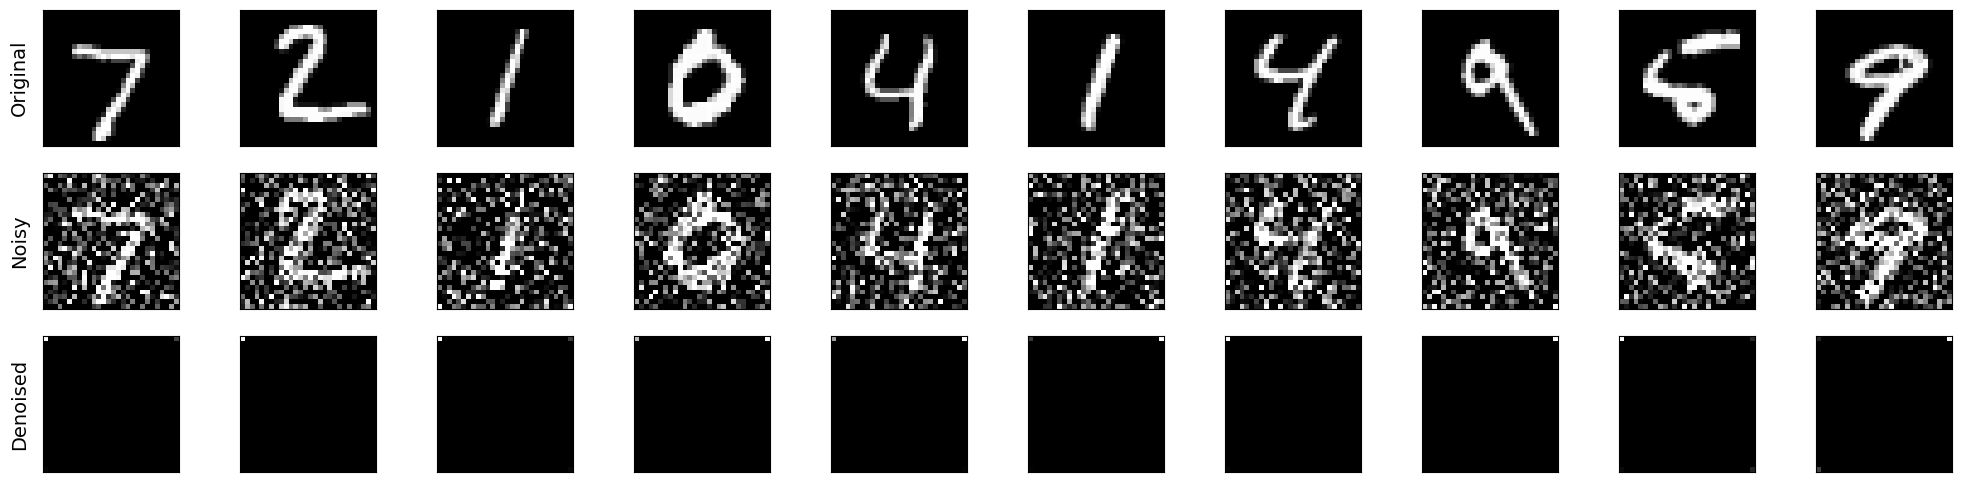

In [21]:
test(model_3,'conv')

## Observations & Analysis

I trained all three models for 20 epochs using the noisy images as the input and the original clean images as the target. After comparing their training and validation losses, along with the reconstructed images, I noticed some clear differences between the models.

### Final Validation Loss (MSE)

| Model         | Val Loss (Epoch 1) |         Val Loss (Epoch 20, best) | Trend                                  |
| ------------- | -----------------: | --------------------------------: | -------------------------------------- |
| FFNN          |             0.0410 | ~0.0393 (plateaued after epoch 3) | Improves at first, then levels off     |
| Transpose CNN |             0.0341 |          0.0310 (still improving) | Steady improvement throughout training |
| Upsampled CNN |             0.1118 |           0.1118 (no improvement) | Stayed almost completely flat          |

### Denoising Performance

Out of the three models, the transpose CNN autoencoder performed the best. Its validation loss dropped from around 0.034 to 0.031 over the 20 epochs and was still slowly decreasing when training ended, so I think it could improve even more with additional epochs. The reconstructed images were also much cleaner, and the digit shapes were still easy to recognize even after adding a lot of noise.

The FFNN performed reasonably well but only improved during the first few epochs. Its validation loss dropped from 0.041 to about 0.0395 within the first three epochs and then barely changed after that. I think this is because the network is very simple, with only a single encoder layer of 32 units, so it doesn't have enough capacity to learn more detailed features. The reconstructed digits looked a little blurry and lost some detail.

The upsampled CNN didn't perform well at all. Its loss stayed almost exactly the same from the beginning to the end of training, and the output images were mostly blank or constant-looking instead of actual reconstructed digits. It basically failed to learn the denoising task.

### Effect of `noise_factor`

I used a `noise_factor` of 0.5, which added a fairly large amount of noise. The noisy images were difficult to recognize, making the denoising task more challenging. If the noise factor was lower, I would expect all three models to perform better since there would be less noise to remove. If it was increased further, I think the transpose CNN would still perform the best, while the FFNN and upsampled CNN would probably struggle even more.

### Training Behavior

None of the models showed signs of overfitting because the training and validation losses stayed very close throughout training. Instead, the FFNN and especially the upsampled CNN appeared to be underfitting, since both models stopped improving early or barely learned at all.

### Challenges Faced

The biggest issue was with the upsampled CNN. Its validation loss stayed around 0.112 for all 20 epochs, and the reconstructed images showed that it wasn't learning useful features. Since the other two models trained correctly using the same dataset, I don't think the problem was with the data itself. My guess is that the learning rate of 0.01 was too high for this model, causing it to get stuck during training. If I were to continue experimenting, I would first try reducing the learning rate to 0.001 and see if that helps.

Another issue was that the notebook contained a few outdated function calls (`np.Inf`, `F.sigmoid`, `F.upsample`, and `dataiter.next()`), which had to be replaced with their current equivalents before the code would run.

### Key Takeaways

Overall, the transpose CNN was clearly the best model for this denoising task. It produced the cleanest reconstructed images and was still improving after 20 epochs. The FFNN worked but was limited by its simple architecture, while the upsampled CNN needs further tuning before it can produce useful results.
